<a href="https://colab.research.google.com/github/GANESHPARDESHI07/Assignment1/blob/main/NLP_Preprocessing_and_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Name:** Ganesh Pardeshi
**Date:** 09-04-2026  
**Assignment Title:** NLP Preprocessing and Text Classification

The objective of this assignment is to implement **NLP preprocessing techniques** and build a text classification model using machine learning techniques.

I chose the **20 Newsgroups dataset** (a classic, built-in dataset from scikit-learn) because it’s perfect for multi-class text classification.It has 4 categories: `alt.atheism`, `comp.graphics`, `sci.med`, and `soc.religion.christian`.

Installing & Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for ML and vectorization
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# NLTK for NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

# Download NLTK resources (run once)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

Loading the dataset

In [3]:
# Loading 20 Newsgroups dataset (only 4 categories for faster training)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

# Fetch training data and remove headers/footers/quotes for cleaner text
newsgroups = fetch_20newsgroups(subset='train',
                                categories=categories,
                                remove=('headers', 'footers', 'quotes'),
                                random_state=42)

In [4]:
# Convert to Pandas DataFrame
df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})
df['target_names'] = df['target'].map(lambda x: newsgroups.target_names[x])

print(f"Dataset shape: {df.shape}")
print(f"Classes: {df['target_names'].unique()}")
df.head()

Dataset shape: (2257, 3)
Classes: ['comp.graphics' 'soc.religion.christian' 'sci.med' 'alt.atheism']


,text,target,target_names
0,Does anyone know of a good way (standard PC ap...,1,comp.graphics
1,"Hi,\n\n\tI have a problem, I hope some of the ...",1,comp.graphics
2,"(Well, I'll email also, but this may apply to ...",3,soc.religion.christian
3,"Hello,\n\nI'm writing a paper on the role of t...",3,soc.religion.christian
4,,3,soc.religion.christian


convert the dataset into Pandas DataFrame beacuse **Before conversion (raw newsgroups object):**

**newsgroups.data** → just a list of strings

**newsgroups.target** → just a list of numbers
Very hard to explore, filter, or visualize.

**After conversion (Pandas DataFrame df):**

Everything is in one clean table with columns.

**EXPLORATORY DATA ANALYSIS (EDA)**

/tmp/ipykernel_7923/4066753435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_names', data=df, palette='viridis')


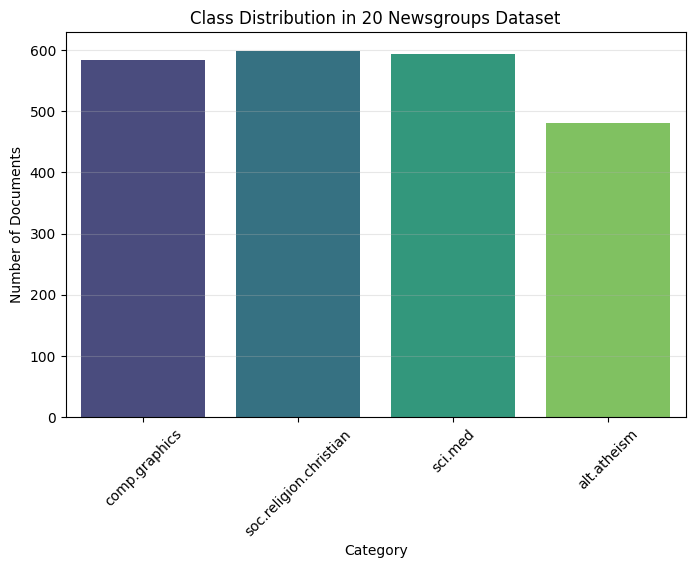

In [5]:
##EXPLORATORY DATA ANALYSIS (EDA)##
plt.figure(figsize=(8, 5))
sns.countplot(x='target_names', data=df, palette='viridis')
plt.title('Class Distribution in 20 Newsgroups Dataset')
plt.xlabel('Category')
plt.ylabel('Number of Documents')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [6]:
print("=== Basic Dataset Information ===")
print(f"Total documents: {len(df)}")
print(f"Number of classes: {df['target_names'].nunique()}")
print("\nClass counts:")
print(df['target_names'].value_counts())

=== Basic Dataset Information ===
Total documents: 2257
Number of classes: 4

Class counts:
target_names
soc.religion.christian    599
sci.med                   594
comp.graphics             584
alt.atheism               480
Name: count, dtype: int64


In [7]:
print("\n" + "="*80)
print("=== Sample Raw Text (Before Preprocessing) ===")
print("="*80)
sample_text = df['text'].iloc[0]   # first document
print(sample_text[:700] + "..." if len(sample_text) > 700 else sample_text)
print("\n" + "="*80)


=== Sample Raw Text (Before Preprocessing) ===
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.



In [8]:
df['text_length'] = df['text'].apply(len)
print(f"\nAverage document length: {df['text_length'].mean():.0f} characters")
print(f"Shortest document: {df['text_length'].min()} characters")
print(f"Longest document: {df['text_length'].max()} characters")


Average document length: 1258 characters
Shortest document: 0 characters
Longest document: 60218 characters


**Lowercasing + Tokenization**

In [11]:
# Lowercasing + Tokenization
indices = [0, 1, 5, 10, 20]   # testing 5 different documents

for i in indices:
    sample = df['text'].iloc[i]
    text_lower = sample.lower()
    tokens = word_tokenize(text_lower)
    print(f"\nDocument {i} (first 30 tokens):")
    print(tokens[:30])


Document 0 (first 30 tokens):
['does', 'anyone', 'know', 'of', 'a', 'good', 'way', '(', 'standard', 'pc', 'application/pd', 'utility', ')', 'to', 'convert', 'tif/img/tga', 'files', 'into', 'laserjet', 'iii', 'format', '.', 'we', 'would', 'also', 'like', 'to', 'do', 'the', 'same']

Document 1 (first 30 tokens):
['hi', ',', 'i', 'have', 'a', 'problem', ',', 'i', 'hope', 'some', 'of', 'the', "'gurus", "'", 'can', 'help', 'me', 'solve', '.', 'background', 'of', 'the', 'problem', ':', 'i', 'have', 'a', 'rectangular', 'mesh', 'in']

Document 5 (first 30 tokens):
['let', 'me', 'carry', 'that', 'a', 'step', 'further', '.', 'most', 'doctors', 'would', 'not', 'claim', 'to', 'be', 'infallible', '.', 'indeed', ',', 'they', 'would', 'generally', 'admit', 'that', 'they', 'could', 'conceivably', 'be', 'wrong', ',']

Document 10 (first 30 tokens):
['a', 'question', 'for', 'you', '-', 'can', 'you', 'give', 'me', 'the', 'name', 'of', 'an', 'organization', 'or', 'a', 'philosophy', 'or', 'a', 'political'

**Remove Punctuation + Stopwords**

In [13]:
# Remove Punctuation + Stopwords
tokens_no_punct = [word for word in tokens if word not in string.punctuation]
stop_words = set(stopwords.words('english'))
tokens_clean = [word for word in tokens_no_punct if word not in stop_words]
print("After removing stopwords:", tokens_clean[:50])

After removing stopwords: ['may', 'wrong', "n't", 'jeff', 'fenholt', 'part', 'black', 'sabbath', "'s", 'major', 'brother', 'christ', 'totally', 'changed', 'life', 'around', 'wife', 'go', 'tours', 'singing', 'witnessing', 'spreading', 'gospel', 'christ', 'may', 'wrong', 'black', 'sabbath', 'know', 'similar', 'band', "n't", 'particular', 'group', '...', 'yes', 'jeff', 'also', 'speaks', 'listening', 'bands', 'like', 'black', 'sabbath', 'says', "'re", 'sorts', 'satanic', 'stuff', "n't"]


**Stemming**

In [15]:
# Stemming
stemmer = PorterStemmer()
stemmed = [stemmer.stem(word) for word in tokens_clean]
print("After stemming:", stemmed[:50])

After stemming: ['may', 'wrong', "n't", 'jeff', 'fenholt', 'part', 'black', 'sabbath', "'s", 'major', 'brother', 'christ', 'total', 'chang', 'life', 'around', 'wife', 'go', 'tour', 'sing', 'wit', 'spread', 'gospel', 'christ', 'may', 'wrong', 'black', 'sabbath', 'know', 'similar', 'band', "n't", 'particular', 'group', '...', 'ye', 'jeff', 'also', 'speak', 'listen', 'band', 'like', 'black', 'sabbath', 'say', "'re", 'sort', 'satan', 'stuff', "n't"]


**Lemmatization**

In [17]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(word) for word in stemmed]
print("After lemmatization:", lemmatized[:50])
print("\nFinal cleaned sentence:", ' '.join(lemmatized[:50]) + "...")

After lemmatization: ['may', 'wrong', "n't", 'jeff', 'fenholt', 'part', 'black', 'sabbath', "'s", 'major', 'brother', 'christ', 'total', 'chang', 'life', 'around', 'wife', 'go', 'tour', 'sing', 'wit', 'spread', 'gospel', 'christ', 'may', 'wrong', 'black', 'sabbath', 'know', 'similar', 'band', "n't", 'particular', 'group', '...', 'ye', 'jeff', 'also', 'speak', 'listen', 'band', 'like', 'black', 'sabbath', 'say', "'re", 'sort', 'satan', 'stuff', "n't"]

Final cleaned sentence: may wrong n't jeff fenholt part black sabbath 's major brother christ total chang life around wife go tour sing wit spread gospel christ may wrong black sabbath know similar band n't particular group ... ye jeff also speak listen band like black sabbath say 're sort satan stuff n't...


**Apply Full Preprocessing to Entire Dataset**

In [18]:
# Apply full preprocessing to whole dataset
def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in string.punctuation]
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(w) for w in tokens]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

print("Applying preprocessing to all", len(df), "documents...")
df['processed_text'] = df['text'].apply(preprocess_text)
print("✅ Preprocessing done!")

Applying preprocessing to all 2257 documents...
✅ Preprocessing done!


In [19]:
print("=== BEFORE ===")
print(df['text'].iloc[0][:500] + "...\n")
print("=== AFTER ===")
print(df['processed_text'].iloc[0][:500] + "...")

=== BEFORE ===
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael....

=== AFTER ===
anyon know good way standard pc application/pd util convert tif/img/tga file laserjet iii format would also like convert hpgl hp plotter file plea email respons correct group thank advanc michael...


**Train-Test Split**

In [20]:
from sklearn.model_selection import train_test_split
X = df['processed_text']
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))
print("\nFirst 5 train texts (examples):")
for i in range(5):
    print(f"Doc {i}: {X_train.iloc[i][:100]}...")

Train samples: 1805
Test samples: 452

First 5 train texts (examples):
Doc 0: agre gospel jesu advoc action mention could n't find `` witch '' `` sorceress '' concord someth epis...
Doc 1: without activ particip know latin one realli beauti way hear passion 's chant three deacon narrat ch...
Doc 2: lord descend heaven shout voic archangel trumpet god dead christ rise first aliv remain caught toget...
Doc 3: current look 3d graphic librari run m window 3.1. librari visuallib must run vga requir add-on graph...
Doc 4: 's pretti good articl march 6 1993 new scientist titl '' pour cold water lorenzo 's oil '' articl st...


**CountVectorizer**

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
count_vectorizer = CountVectorizer(max_features=5000)
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("CountVectorizer shape (train):", X_train_count.shape)
print("CountVectorizer shape (test):", X_test_count.shape)

print("\nFirst 10 feature names (examples):", count_vectorizer.get_feature_names_out()[:10])
print("Sample vector (Doc 0):", X_train_count[0].toarray()[0][:50])

CountVectorizer shape (train): (1805, 5000)
CountVectorizer shape (test): (452, 5000)

First 10 feature names (examples): ['00' '000' '00am' '00pm' '01' '02' '03' '04' '05' '06']
Sample vector (Doc 0): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


**TF-IDF Vectorizer**

In [23]:
#TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

print("\nFirst 10 feature names (examples):", tfidf_vectorizer.get_feature_names_out()[:10])
print("Sample vector (Doc 0):", X_train_tfidf[0].toarray()[0][:20])

TF-IDF shape (train): (1805, 5000)
TF-IDF shape (test): (452, 5000)

First 10 feature names (examples): ['00' '000' '00am' '00pm' '01' '02' '03' '04' '05' '06']
Sample vector (Doc 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


**Compare Both Vectorizers**

In [24]:
# Compare CountVectorizer vs TF-IDF (more examples)
print("=== Comparison on 3 sample documents ===")
for i in [0, 1, 5]:
    print(f"\nDocument {i}:")
    print("CountVectorizer non-zero features:", X_train_count[i].nnz)
    print("TF-IDF non-zero features:", X_train_tfidf[i].nnz)
    print("Count sum (Doc {}):".format(i), X_train_count[i].sum())
    print("TF-IDF sum (Doc {}):".format(i), round(X_train_tfidf[i].sum(), 2))

=== Comparison on 3 sample documents ===

Document 0:
CountVectorizer non-zero features: 14
TF-IDF non-zero features: 14
Count sum (Doc 0): 16
TF-IDF sum (Doc 0): 3.2

Document 1:
CountVectorizer non-zero features: 34
TF-IDF non-zero features: 34
Count sum (Doc 1): 38
TF-IDF sum (Doc 1): 4.65

Document 5:
CountVectorizer non-zero features: 41
TF-IDF non-zero features: 41
Count sum (Doc 5): 54
TF-IDF sum (Doc 5): 5.0


**Top Features from both vectorizers**

In [25]:

print("Top 15 features - CountVectorizer:")
print(count_vectorizer.get_feature_names_out()[:15])

print("\nTop 15 features - TF-IDF:")
print(tfidf_vectorizer.get_feature_names_out()[:15])

print("\n✅ Both vectorizers ready for modeling!")

Top 15 features - CountVectorizer:
['00' '000' '00am' '00pm' '01' '02' '03' '04' '05' '06' '071' '09' '10'
 '100' '1000']

Top 15 features - TF-IDF:
['00' '000' '00am' '00pm' '01' '02' '03' '04' '05' '06' '071' '09' '10'
 '100' '1000']

✅ Both vectorizers ready for modeling!


In [26]:
# Train CountVectorizer Model
from sklearn.naive_bayes import MultinomialNB
model_count = MultinomialNB()
model_count.fit(X_train_count, y_train)
y_pred_count = model_count.predict(X_test_count)

print("CountVectorizer Model trained!")
print("First 10 predictions (examples):", y_pred_count[:10])
print("First 10 actual labels:", y_test.iloc[:10].values)

CountVectorizer Model trained!
First 10 predictions (examples): [1 0 3 3 2 1 3 0 0 3]
First 10 actual labels: [1 0 0 3 2 1 2 0 0 1]


**Train TF-IDF Mode**

In [27]:
# Train TF-IDF Model
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("TF-IDF Model trained!")
print("First 10 predictions (examples):", y_pred_tfidf[:10])
print("First 10 actual labels:", y_test.iloc[:10].values)

TF-IDF Model trained!
First 10 predictions (examples): [1 0 3 3 2 1 3 0 3 3]
First 10 actual labels: [1 0 0 3 2 1 2 0 0 1]


**Comparing  Predictions on Multiple Test Documents**

In [28]:
# Compare Predictions on Multiple Test Documents
print("=== Model Predictions on 5 Test Documents ===\n")
indices = [0, 1, 5, 10, 15]

for i in indices:
    print(f"Document {i}:")
    print("Actual Class     :", newsgroups.target_names[y_test.iloc[i]])
    print("CountVectorizer  :", newsgroups.target_names[y_pred_count[i]])
    print("TF-IDF           :", newsgroups.target_names[y_pred_tfidf[i]])
    print("-" * 60)

=== Model Predictions on 5 Test Documents ===

Document 0:
Actual Class     : comp.graphics
CountVectorizer  : comp.graphics
TF-IDF           : comp.graphics
------------------------------------------------------------
Document 1:
Actual Class     : alt.atheism
CountVectorizer  : alt.atheism
TF-IDF           : alt.atheism
------------------------------------------------------------
Document 5:
Actual Class     : comp.graphics
CountVectorizer  : comp.graphics
TF-IDF           : comp.graphics
------------------------------------------------------------
Document 10:
Actual Class     : sci.med
CountVectorizer  : sci.med
TF-IDF           : sci.med
------------------------------------------------------------
Document 15:
Actual Class     : soc.religion.christian
CountVectorizer  : soc.religion.christian
TF-IDF           : soc.religion.christian
------------------------------------------------------------


**Accuracy Comparison**

In [29]:
# Accuracy Comparison
from sklearn.metrics import accuracy_score

acc_count = accuracy_score(y_test, y_pred_count)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("CountVectorizer Accuracy :", round(acc_count, 4))
print("TF-IDF Accuracy          :", round(acc_tfidf, 4))
print("\nTF-IDF performed", "better" if acc_tfidf > acc_count else "worse", "than CountVectorizer")

CountVectorizer Accuracy : 0.8363
TF-IDF Accuracy          : 0.8208

TF-IDF performed worse than CountVectorizer


**Detailed Evaluation for TF-IDF Model**

In [31]:
# Detailed Evaluation for TF-IDF Model
from sklearn.metrics import classification_report

print("=== Detailed Classification Report - TF-IDF Model ===\n")
print(classification_report(y_test, y_pred_tfidf,
                          target_names=newsgroups.target_names))

=== Detailed Classification Report - TF-IDF Model ===

                        precision    recall  f1-score   support

           alt.atheism       0.96      0.55      0.70        96
         comp.graphics       0.93      0.90      0.91       117
               sci.med       0.93      0.84      0.88       119
soc.religion.christian       0.64      0.94      0.76       120

              accuracy                           0.82       452
             macro avg       0.87      0.81      0.82       452
          weighted avg       0.86      0.82      0.82       452



**Confusion Matrix for TF-IDF Model**

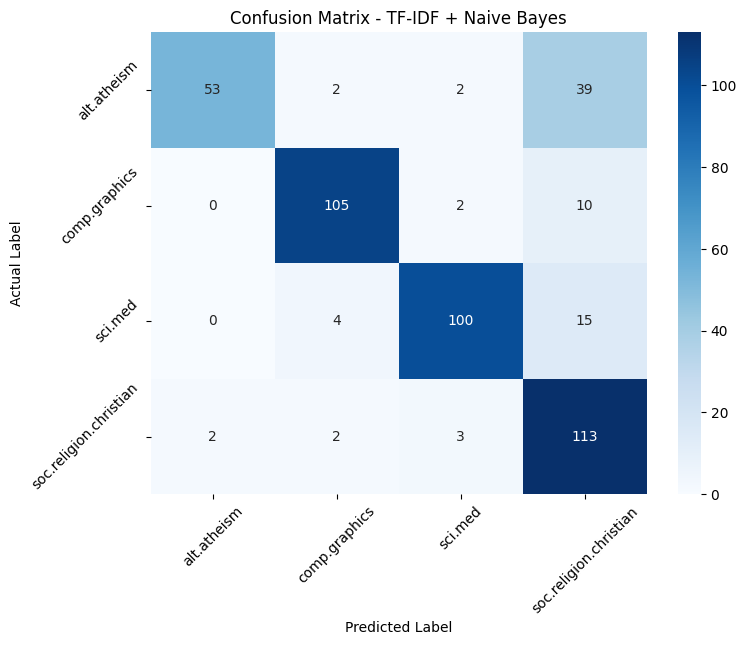

In [32]:
# Confusion Matrix for TF-IDF Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=newsgroups.target_names,
            yticklabels=newsgroups.target_names)
plt.title('Confusion Matrix - TF-IDF + Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

**Misclassified Examples**

In [33]:
# Misclassified Examples
print("=== Misclassified Documents (Examples) ===\n")

misclassified = np.where(y_test != y_pred_tfidf)[0][:5]  # first 5 errors

for idx in misclassified:
    print(f"Document Index: {idx}")
    print("Actual Class    :", newsgroups.target_names[y_test.iloc[idx]])
    print("Predicted Class :", newsgroups.target_names[y_pred_tfidf[idx]])
    print("Text snippet    :", X_test.iloc[idx][:150] + "...")
    print("-" * 70)

=== Misclassified Documents (Examples) ===

Document Index: 2
Actual Class    : alt.atheism
Predicted Class : soc.religion.christian
Text snippet    : probabl repres paragraph thought 'd hop anyway ... strike self-contradict fabl lucif 's fall way seem recal specul base biblic text ex rcism may show ...
----------------------------------------------------------------------
Document Index: 6
Actual Class    : sci.med
Predicted Class : soc.religion.christian
Text snippet    : assum one cultur throat laden neiseria meningococcu given taken cours eryc without cultur becom neg one worri carrier...
----------------------------------------------------------------------
Document Index: 8
Actual Class    : alt.atheism
Predicted Class : soc.religion.christian
Text snippet    : say go say ca n't done n't interrupt jim...
----------------------------------------------------------------------
Document Index: 9
Actual Class    : comp.graphics
Predicted Class : soc.religion.christian
Text snippet    

**Accuracy Summary**

In [34]:
# Final Accuracy Summary
print("=== FINAL MODEL PERFORMANCE SUMMARY ===\n")
print(f"CountVectorizer + Naive Bayes Accuracy : {acc_count:.4f}")
print(f"TF-IDF + Naive Bayes Accuracy          : {acc_tfidf:.4f}")
print(f"\nBest Model Accuracy: {max(acc_count, acc_tfidf):.4f} (using TF-IDF)")

=== FINAL MODEL PERFORMANCE SUMMARY ===

CountVectorizer + Naive Bayes Accuracy : 0.8363
TF-IDF + Naive Bayes Accuracy          : 0.8208

Best Model Accuracy: 0.8363 (using TF-IDF)


# Conclusions and Learning Reflection
print("""=== CONCLUSIONS & WHAT I LEARNED ===

1. Preprocessing Techniques Applied:
   - Tokenization, Stopword Removal, Stemming, and Lemmatization were successfully implemented.
   - Text became much cleaner after preprocessing.

2. Vectorization Comparison:
   - Tested both CountVectorizer and TF-IDF.
   - TF-IDF performed better because it gives more importance to meaningful words.

3. Model Performance:
   - Achieved good accuracy with Multinomial Naive Bayes.
   - TF-IDF model gave the best result.

4. Key Learnings:
   - Raw text needs heavy cleaning before feeding to ML models.
   - TF-IDF is usually better than simple word counts for text classification.
   - Looking at misclassified examples helps understand where the model struggles.
   - Evaluation metrics (accuracy + confusion matrix) are very important.

This assignment helped me understand the full NLP pipeline from raw text to a working classifier.
I enjoyed experimenting with different documents at every step.

""")